<a href="https://colab.research.google.com/github/Morganjools/PRA3024/blob/main/LHCb_2026_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 3!

We will be focussing in Particle Physics Analysis and detecting matter/antimatter assymetries in the production of certain types of particles.


![LHCb detector](https://www1b.physik.rwth-aachen.de/~schael/LHCb_files/LHCB%20PREVIEW-white-bg.jpg)

The data we are using comes from LHCb - one of the experiments at LHC. It is a highly specialised detector aimed at detecting decays involving the B-quark. Unlike the other major experiments, LHCb detects particles very close to the source and looks almost exclusively in the forward direction - this gives the detector many advantages compared to other experiments at LHC.

In order to get started, we need to access the [ROOT framework](https://root.cern.ch/) through a python package for that - [upROOT](https://pypi.org/project/uproot/) and download some datafiles into your environment!.

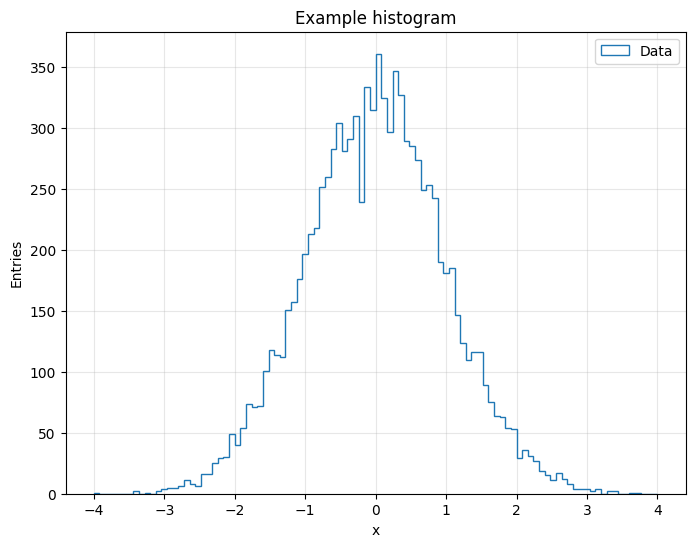

In [1]:
# We use NumPy for numerical work and random numbers
# Matplotlib is used for plotting as before
import numpy as np
import matplotlib.pyplot as plt

# SciPy provides fitting tools, similar to ROOT's Fit("gaus")
from scipy.stats import norm


# ------------------------------------------------------------
# 1. Generate Gaussian-distributed random numbers
#    (equivalent to h.FillRandom("gaus"))
# ------------------------------------------------------------

# Mean (mu) and standard deviation (sigma) of the Gaussian
mu = 0.0
sigma = 1.0

# Number of entries to generate (like number of fills)
n_entries = 10000

# Generate random data
data = np.random.normal(loc=mu, scale=sigma, size=n_entries)


# ------------------------------------------------------------
# 2. Create a histogram (We will do this alot today...))
# ------------------------------------------------------------

# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -4, 4

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)


# ------------------------------------------------------------
# 3. Labels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot
plt.show()



All being well - this should give no errors and we should have some kind of Gaussian distribution above.

We now want to do two things, install uproot - and get our data file from the CERN open data storage location.

This will probably be ratelimited very quickly, so you can find it on Canvas here: https://canvas.maastrichtuniversity.nl/courses/26553/files/6101104?module_item_id=1009080

Then upload it directly.

In [2]:
!pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 41.7 MB/s eta 0:00:00


In [3]:
!mkdir LHCb_Data && cd LHCb_Data && wget http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root

--2026-02-24 17:44:35--  http://opendata.cern.ch/record/4900/files/B2HHH_MagnetDown.root
Resolving opendata.cern.ch (opendata.cern.ch)... 137.138.6.31, 2001:1458:201:8b::100:1c8
Connecting to opendata.cern.ch (opendata.cern.ch)|137.138.6.31|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 666484974 (636M) [application/octet-stream]
Saving to: ‘B2HHH_MagnetDown.root’

B2HHH_MagnetDown.ro 100%[===================>] 635.61M  45.4MB/s    in 76s     

2026-02-24 17:45:51 (8.33 MB/s) - ‘B2HHH_MagnetDown.root’ saved [666484974/666484974]



In [4]:
import uproot

# Open the ROOT file
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

# List contents (shows us what is inside)
file.keys()

# Access the tree
tree = file["DecayTree"]

# Read one branch as a NumPy array
px = tree["H1_PX"].array(library="np")

px

array([  375.2842054 , -4985.13078543, -1265.45654435, ...,
        2606.91083928,  -294.71098895,   499.04234923])

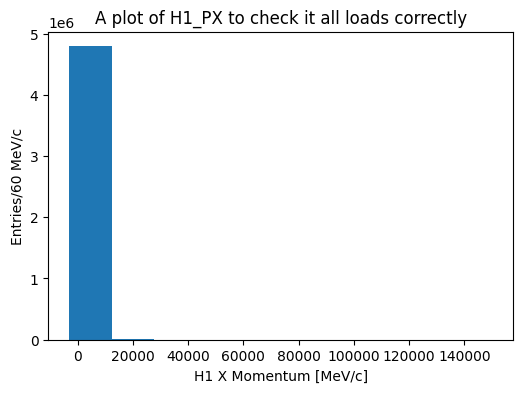

In [5]:
# now our data is an array - we can plot it :)

plt.figure(figsize=(6, 4))


#play with the variables below ...
plt.hist(
    px,
    bins=10,
    range=(-3000, 150000),
    histtype="bar"
)

#Add some labels...

plt.xlabel("H1 X Momentum [MeV/c]")
plt.ylabel("Entries/60 MeV/c")
plt.title("A plot of H1_PX to check it all loads correctly")

plt.show()

This is the point at which the setup is all working - you can proceed below if you want to look at a basic guide to fitting functions to data using numpy etc.

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1942987541.py:44: SyntaxWarning: invalid escape sequence '\m'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
/tmp/ipython-input-1942987541.py:44: SyntaxWarning: invalid escape sequence '\s'
  label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"


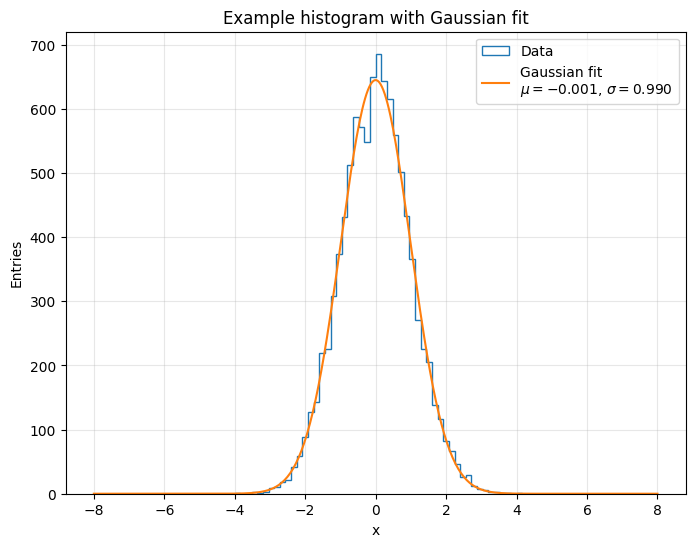

In [6]:
# Histogram settings - choose your own
n_bins = 100
x_min, x_max = -8, 8

# Create the figure and axes
fig, ax = plt.subplots(figsize=(8, 6))


counts, bin_edges, _ = ax.hist(
    data,
    bins=n_bins,
    range=(x_min, x_max),
    histtype="step",
    label="Data"
)

# ------------------------------------------------------------
# Now we perform a Gaussian fit
# ------------------------------------------------------------

# Fit a normal distribution to the data
# norm.fit returns the fitted mean and standard deviation
fit_mu, fit_sigma = norm.fit(data)

# Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

# Evaluate the fitted Gaussian probability density function
pdf = norm.pdf(x, fit_mu, fit_sigma)

# Convert PDF to expected histogram counts
# (ROOT does this internally; here we scale manually)
bin_width = (x_max - x_min) / n_bins
fit_y = pdf * n_entries * bin_width


# ------------------------------------------------------------
# Draw the fitted Gaussian on top of the histogram
# ------------------------------------------------------------

ax.plot(
    x,
    fit_y,
    label=f"Gaussian fit\n$\mu={fit_mu:.3f}$, $\sigma={fit_sigma:.3f}$"
)


# ------------------------------------------------------------
# abels, title, and final touches
# ------------------------------------------------------------

ax.set_title("Example histogram with Gaussian fit")
ax.set_xlabel("x")
ax.set_ylabel("Entries")

ax.legend()
ax.grid(alpha=0.3)

# Display the plot (equivalent to c.Draw())
plt.show()


## If you are **Here** - and Chris did not make the introduction yet - it's time for a coffee - take a break and wait for instructions about how to proceed.

#Why are we here?

This week is about finding out something about one of the fundemental questions in physics. Why do we have "stuff".

According to many of our models, and according to many measurements in particle physics, matter and anti-matter appear to be produced in equal quantities.

However, when one looks at the Universe in general, we have more matter than anti-matter left - so there need to be some processes where anti-matter and matter are not produced equally. You can find out more about the Matter/Anti-Matter Asymmetry [here](http://press.web.cern.ch/backgrounders/matterantimatter-asymmetry)

One place we look for this asymetry is in [charge-partity (CP) violation](https://www.symmetrymagazine.org/article/october-2005/explain-it-in-60-seconds) in particle physics processes. This essentially says that the processes that happen in the anti-particle version of a decay do not **exactly** match to the processes that happen in the particle version of the decay.



---



At LHCb, we produce both particle of the  B<sup>+</sup> meson and it's antiparticle the B<sup>-</sup> meson.

We cannot detect these mesons directly. They decay into other things before we have a chance to measure them properly. So we collect data on the decay products, often called daughter particles. There are 524 [documented](http://pdg.lbl.gov/2014/listings/rpp2014-list-B-plus-minus.pdf) ways that the B<sup>+/-</sup> decays into various combinations. In order to simplify the process, we choose decay combinations that are convenient or have particular properties.

In this analysis, we will take the process:-

B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>


To do so, we are given the following data for each event in our system:-

![alt text](https://raw.githubusercontent.com/lhcb/opendata-project/80d64a3796e593fc8f9b257e85f32ae2e54f131f/Images/Variables.png)

Here, H1 is the detected daughter particle (so a Kaon or a Pion), **not** the B-meson - the mother particle. Normally we would have to do some reconstruction from the decay products (the Daughters) to the Mother to be able to make some conclusions.

Let's get started with working with this data:

For our analysis, the momentum of each of the daughter particles is split into the three cartesian components. We have combined these into a variable called H1_Ptot

In [7]:
#Using Uproot, load your data file and load the variables you think are useful for this analysis - I recommend learning what your data structure is...so plotting and calculations becomes easier later.

In [8]:
#B-meson decays into three daughter particles (H1, H2, H3)
file = uproot.open("/content/LHCb_Data/B2HHH_MagnetDown.root")

#As before reading one branch as numpy array and extracting the components from the file
H1_PX = file["DecayTree"]["H1_PX"].array(library="np")
H1_PY= file["DecayTree"]["H1_PY"].array(library="np")
H1_PZ= file["DecayTree"]["H1_PZ"].array(library="np")

#Function to find total momentum for H1
P_H1= (H1_PX**2+H1_PY**2+H1_PZ**2)**0.5


#Do the same for H2 and H3
H2_PX = file["DecayTree"]["H2_PX"].array(library="np")
H2_PY= file["DecayTree"]["H2_PY"].array(library="np")
H2_PZ= file["DecayTree"]["H2_PZ"].array(library="np")

P_H2= (H2_PX**2+H2_PY**2+H2_PZ**2)**0.5

H3_PX = file["DecayTree"]["H3_PX"].array(library="np")
H3_PY= file["DecayTree"]["H3_PY"].array(library="np")
H3_PZ= file["DecayTree"]["H3_PZ"].array(library="np")

P_H3= (H3_PX**2+H3_PY**2+H3_PZ**2)**0.5

print(P_H1)
print(P_H2)
print(P_H3)

[ 51828.26 326248.07  90801.38 ...  37255.64  35914.59   5211.04]
[17726.53  5326.76 17930.28 ...  6354.76  7742.33 22131.77]
[105880.07  87691.75  85586.15 ...  10712.21 113934.88 114852.53]


In [9]:
#Here make a plot of the Total momentum of each of the three daughters on one plot

In [10]:
tree.keys() #To see what we have in the file

['B_FlightDistance',
 'B_VertexChi2',
 'H1_PX',
 'H1_PY',
 'H1_PZ',
 'H1_ProbK',
 'H1_ProbPi',
 'H1_Charge',
 'H1_IPChi2',
 'H1_isMuon',
 'H2_PX',
 'H2_PY',
 'H2_PZ',
 'H2_ProbK',
 'H2_ProbPi',
 'H2_Charge',
 'H2_IPChi2',
 'H2_isMuon',
 'H3_PX',
 'H3_PY',
 'H3_PZ',
 'H3_ProbK',
 'H3_ProbPi',
 'H3_Charge',
 'H3_IPChi2',
 'H3_isMuon']

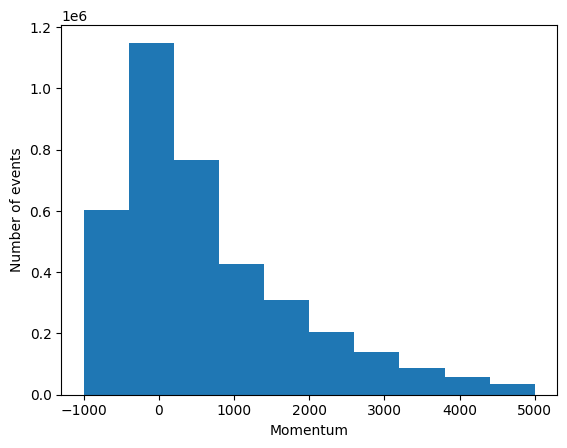

In [11]:
#With this function you can assign a specific branch, in this case H1_PX
branches = tree.arrays()
plt.hist(branches['H1_PX'], bins=10, range=(-1000,5000))
plt.xlabel('Momentum')
plt.ylabel('Number of events')
plt.show()

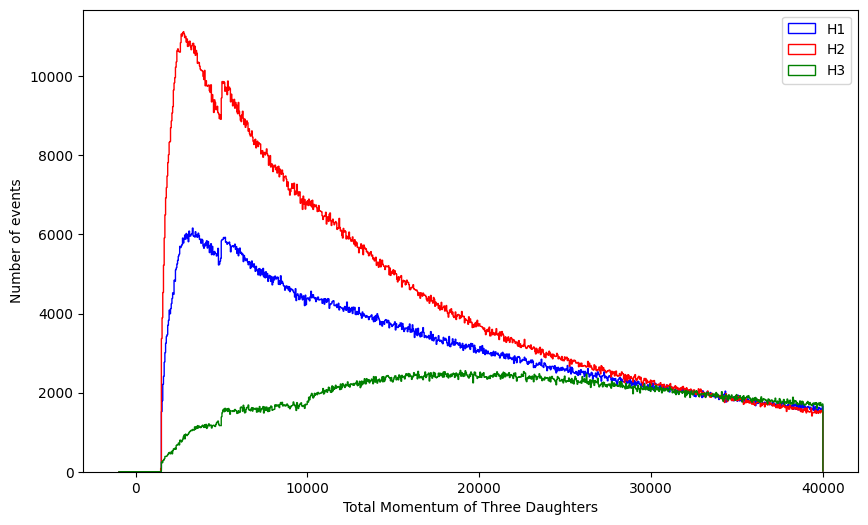

In [12]:
#Plotting the total momenta of the daughter particles in 1 plot
plt.figure(figsize=(10, 6))
plt.hist([P_H1], bins=1000, range=(-1000,40000), color='blue', alpha=1, histtype='step', linewidth=1)
plt.hist([P_H2], bins=1000, range=(-1000,40000), color='red', alpha=1, histtype='step', linewidth=1)
plt.hist([P_H3], bins=1000, range=(-1000,40000), color='green', alpha=1, histtype='step', linewidth=1)
plt.xlabel('Total Momentum of Three Daughters')
plt.ylabel('Number of events')
plt.legend(['H1', 'H2', 'H3'])
plt.show()

Now plot the total momentum for the mother (M_Ptot) this about how to calculate this from the information available

In [13]:
#use the histogram plotting tools, plot the momentum of the mother

[175372.20820906 419256.08430844 194255.99782005 ...  54114.76587451
 157529.80431186 142125.00757485]


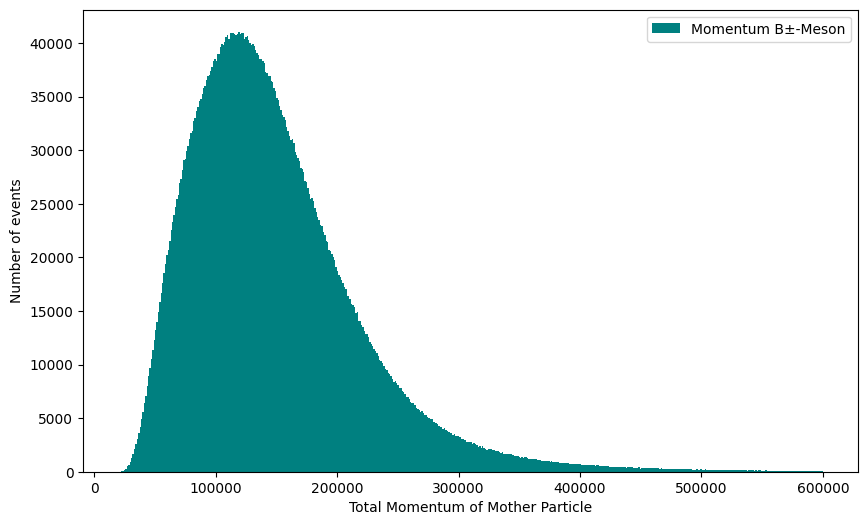

In [14]:
#Finding the total mother momentum with this function
M_Ptot= ((H1_PX+ H2_PX + H3_PX)**2+ (H1_PY+ H2_PY+ H3_PY)**2 + (H1_PZ+ H2_PZ+ H3_PZ)**2)**0.5
print(M_Ptot)

#Plotting the mother momentum
plt.figure(figsize=(10, 6))
plt.hist([M_Ptot], bins=500, range=(20000,600000), color='teal', alpha=1)
plt.xlabel('Total Momentum of Mother Particle')
plt.ylabel('Number of events')
plt.legend(['Momentum B±-Meson'])
plt.show()

Let's take a look at the whole data file that is available to us by looking at one specific entry - for example the number 45th entry in your array...

In [15]:
# print the 45th entry from your array(s) together with the variable name, maybe in a nice list or table.

In [37]:
#Assuming zero-based indexing and visualizing the file as before, but now assigning a specific row
data45 = tree.arrays(entry_start=44, entry_stop=45, library="np")

#Printing as a table
print(f"{'Column':<30} {'Value'}") #Spacing between columns
print("-" * 50)
for col, val in data45.items():
    print(f"{col:<30} {val[0]}")

Column                         Value
--------------------------------------------------
B_FlightDistance               5.333712849447322
B_VertexChi2                   6.083737391154093
H1_PX                          -1634.778090943406
H1_PY                          838.6625674548812
H1_PZ                          15416.880380015971
H1_ProbK                       0.002000361680984497
H1_ProbPi                      0.9490910768508911
H1_Charge                      1
H1_IPChi2                      312.78471360147006
H1_isMuon                      0
H2_PX                          -3456.1594387288615
H2_PY                          -328.7925226754248
H2_PZ                          21752.773751811932
H2_ProbK                       0.0034507811069488525
H2_ProbPi                      0.9238651394844055
H2_Charge                      -1
H2_IPChi2                      301.67891283020924
H2_isMuon                      0
H3_PX                          -2892.8286712088047
H3_PY                    

We have now completed the initial steps and begun to work through what we need to with the data. This is a perfect moment to take a coffee!

Having discovered all of the relevant information about our daughter particles, we need to combine the measurements about them into a single mother - which will be our B<sup>+</sup> or our B<sup>-</sup>

Having found our momentum and energy, we can use these quantities to find our experimental mass (not the theoretical mass as we have used for the reconstruction).

When we calculate this, we will get a distribution of masses. This is due to errors in the measurements made either by the detector, or in the experiment itself. We hope to have a reasonably narrow peak to work with, but, sometimes this is not possible.

Additionally there will be other particles in the detector - which means our daughters might have come from two or even three different processes. Events which don't come from the same process will give a higher or lower mass than we are looking for. This is typically called the *background* while events which come from our event of interest are called the *signal*

Stored 5135823 events; columns: [E_B, P_B, M_B]


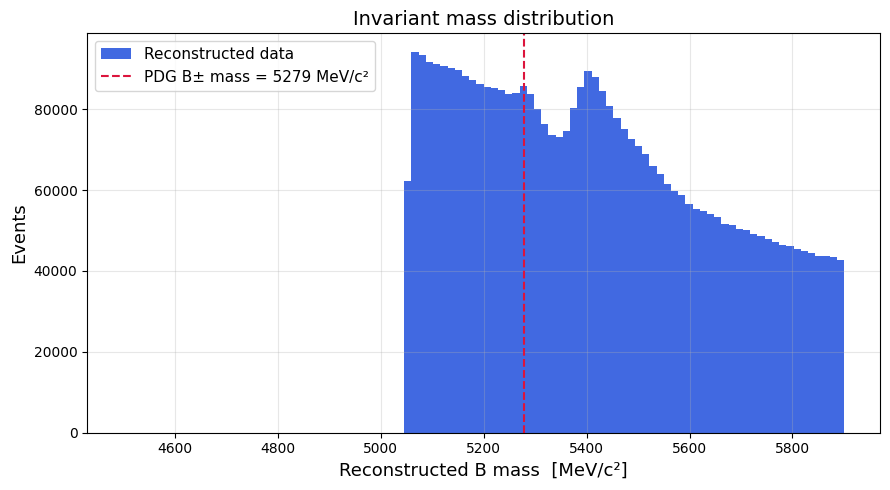

In [17]:
#Computing the energy of the daughters first
#Use the relativistic energy-momentum relation: E² = p²c² + m²c⁴
#Assume natural units (c = 1): E = sqrt(p² + m²)

m_K = 494 #MeV/c^2; mass of kaon particle, obtained from: https://nl.wikipedia.org/wiki/Kaon

E_H1 = np.sqrt(P_H1**2 + m_K**2)
E_H2 = np.sqrt(P_H2**2 + m_K**2)
E_H3 = np.sqrt(P_H3**2 + m_K**2)

#The energy of the mother particle is the sum of daughter particle energies
E_M   = E_H1 + E_H2 + E_H3

#Addition of daughter momenta to find mother momentum
PX_M  = H1_PX + H2_PX + H3_PX
PY_M  = H1_PY + H2_PY + H3_PY
PZ_M  = H1_PZ + H2_PZ + H3_PZ

#Function for find the mother momentum, renaming it to make it more clear, but it is the same equation used in the previous exercise
P_M   = np.sqrt(PX_M**2 + PY_M**2 + PZ_M**2)

#The using the total momentum find the reconstructed mass of the B (mass obtained from energy and momentum of its decay products)
#Use the energy momentum relation, obtained from: https://en.wikipedia.org/wiki/Invariant_mass
m_M_squared = E_M**2 - P_M**2
m_M    = np.sqrt(np.maximum(m_M_squared, 0))  #Guard against tiny negative values, to not get negative results


#Now write the new variables to an array
results = np.column_stack([E_M, P_M, m_M])
print(f"Stored {len(results)} events; columns: [E_B, P_B, M_B]")


#Now plot a histogram of the range of masses of the B meson.
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(m_M, bins=100, range=(4500, 5900), color="royalblue", linewidth=0.4, label="Reconstructed data")

#PDG value for B± mass: 5279.34 MeV/c²
#Obtained from: R.L. Workman et al. (Particle Data Group), Prog.Theor.Exp.Phys. 2022, 083C01 (2022)
pdg_mass = 5279.34
ax.axvline(pdg_mass, color="crimson", linestyle="--", linewidth=1.5, label=f"PDG B± mass = {pdg_mass:.0f} MeV/c²")

ax.set_xlabel("Reconstructed B mass  [MeV/c²]", fontsize=13)
ax.set_ylabel("Events", fontsize=13)
ax.set_title("Invariant mass distribution", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# **Answers to theory:**
#Does this match what we would expect from theory?
In theory, the pdg mass should be around the peak of the reconstructed mass to confirm we are observing K particles. There is a slight peak around the pdg mass, but it could be that there is still noise from other particles or from the equipment.

#What are the features of your plot that you see?
There is a peak around 5400 MeV/c^2, and a slight gaussian distribution around this peak. However, the pdg mass is 5279 MeV/c^2, so that indicates that we are not observing pure B meson decay.

**Next Exercise**

We know that some of our particles are the B+ and some are the B- particle. There will also be some particles in our system that are not coming from a genuine B+/- or are a B+/- but are not constructed from Kaons.

We have some tools available to help:-

  *  During detection, software attributes the probability of a particle being a Kaon or a Pion (in the H1_ProbK or H1_ProbPi variable)
  * The detector also knows if the particle was a Muon - since it has detectors specifically for these. So it can attribute a 0 or a 1 to this probability
  * The reconstructed vertex has a some kind of quality associated with it (we call this the Vertex χ2 (this is the variable B_VertexChi2). This is the statistical measure that determines how well we found a single point to be the source of all three particles.



In order to get a better result, we should select our data to have the properties we desire and make some rules (often called a selection) to cut away data we don't want to include for various reasons. e.g. we know we don't have any muons in our decay - so any time H1/H2/H3 are a muon they should be excluded. The other variables are not so clear - so we can plot them to make a decision.

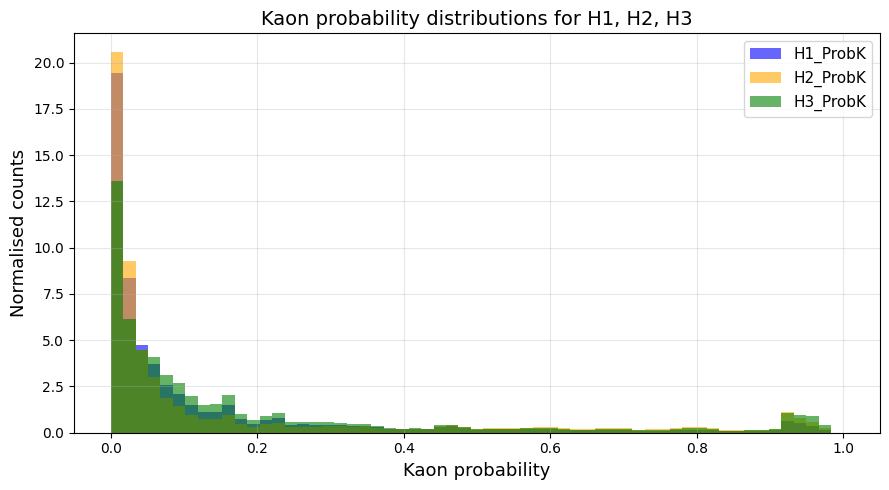

In [18]:
#Make plots of H1/H2/H3 _ProbK on one plot
#First extract the needed components from the file as we did before
H1_ProbK  = branches["H1_ProbK"];  H2_ProbK  = branches["H2_ProbK"];  H3_ProbK  = branches["H3_ProbK"]
H1_ProbPi = branches["H1_ProbPi"]; H2_ProbPi = branches["H2_ProbPi"]; H3_ProbPi = branches["H3_ProbPi"]
H1_isMuon = branches["H1_isMuon"]; H2_isMuon = branches["H2_isMuon"]; H3_isMuon = branches["H3_isMuon"]
B_VertexChi2 = branches["B_VertexChi2"]

#Plotting
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(0, 1, 60) #From: https://numpy.org/doc/stable/reference/generated/numpy.linspace.html
ax.hist(H1_ProbK, bins=bins, alpha=0.6, color="blue",  label="H1_ProbK", density=True)
ax.hist(H2_ProbK, bins=bins, alpha=0.6, color="orange", label="H2_ProbK", density=True)
ax.hist(H3_ProbK, bins=bins, alpha=0.6, color="green",   label="H3_ProbK", density=True)

ax.set_xlabel("Kaon probability", fontsize=13)
ax.set_ylabel("Normalised counts", fontsize=13)
ax.set_title("Kaon probability distributions for H1, H2, H3", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

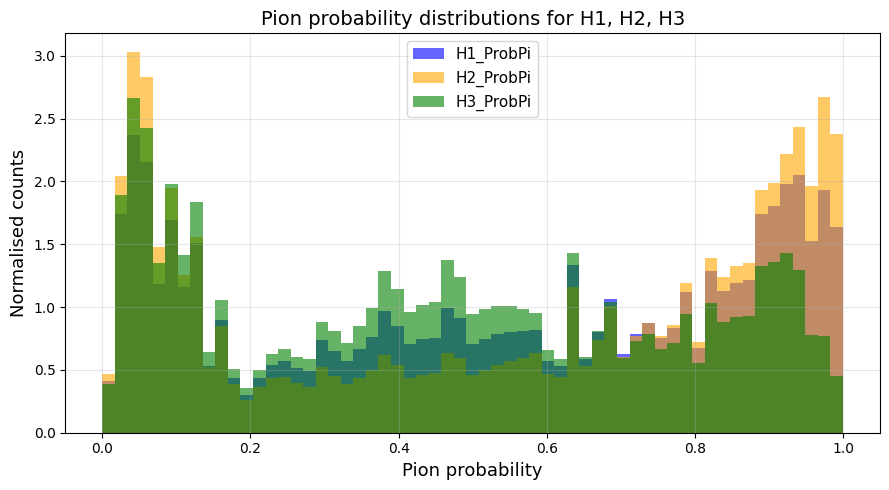

In [19]:
#Do the same for the probability of pions
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(0, 1, 60)
ax.hist(H1_ProbPi, bins=bins, alpha=0.6, color="blue",  label="H1_ProbPi", density=True)
ax.hist(H2_ProbPi, bins=bins, alpha=0.6, color="orange", label="H2_ProbPi", density=True)
ax.hist(H3_ProbPi, bins=bins, alpha=0.6, color="green",   label="H3_ProbPi", density=True)

ax.set_xlabel("Pion probability", fontsize=13)
ax.set_ylabel("Normalised counts", fontsize=13)
ax.set_title("Pion probability distributions for H1, H2, H3", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

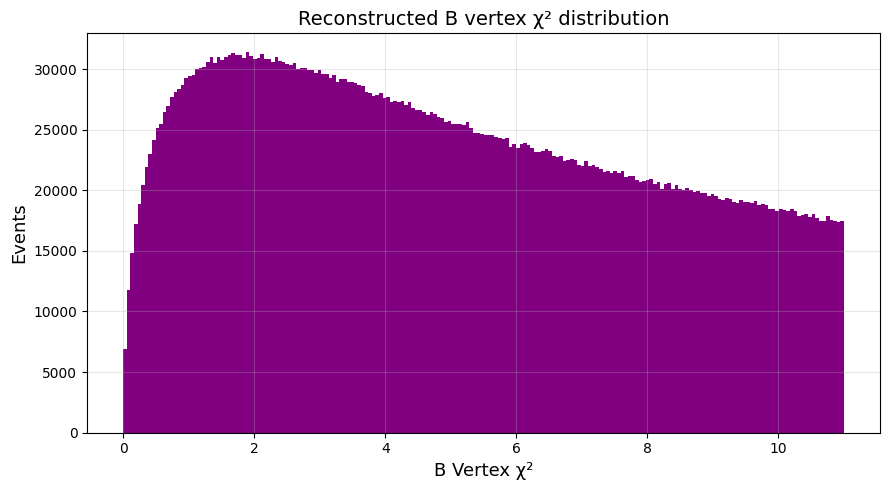

In [20]:
#For all our particles, make a plot of the B_VertexChi2
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(B_VertexChi2, bins=200, range=(0, 11), color="purple", linewidth=0.4)

ax.set_xlabel("B Vertex χ²", fontsize=13)
ax.set_ylabel("Events", fontsize=13)
ax.set_title("Reconstructed B vertex χ² distribution", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Using these plots, we can now make a preselection string. This is a text string that looks like

In [21]:
#This example is for each daughter particle to have a Probability of being a Pion being more than 90% and H1 to not be a muon
#This is not a good choice of selection - you should make your own :)
selection=("H1_ProbPi>0.9&H2_ProbPi>0.9&H3_ProbPi>0.9&!H1_isMuon&H2_isElectron&H3_isElephant")

In [22]:
#Look at the total number of entries originally and the new number - how much of your data did you throw away? Was this a good idea? :(

In [23]:
#Now as a good check, we should see the effect of applying our cuts.
#On one histogram, plot the B meson mass, from both the tree (pre-cuts) and the CutTree (post-cuts)
#What do you notice about your histogram now?


In [24]:
#You can also plot your selected data alone - this shape probably looks quite alot different to your first distribution!

Events before selection :  5,135,823
Events after  selection :     10,976



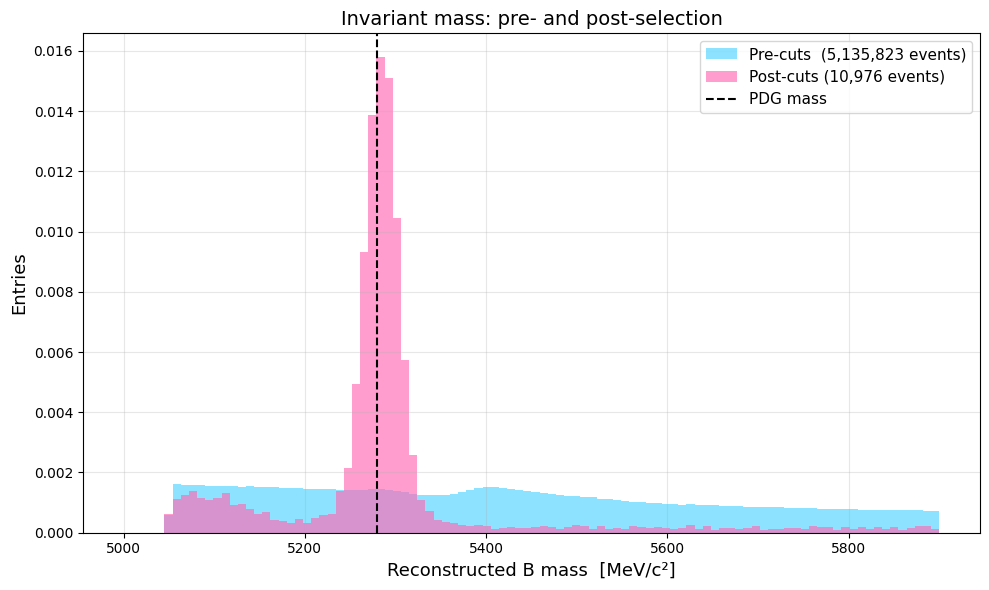

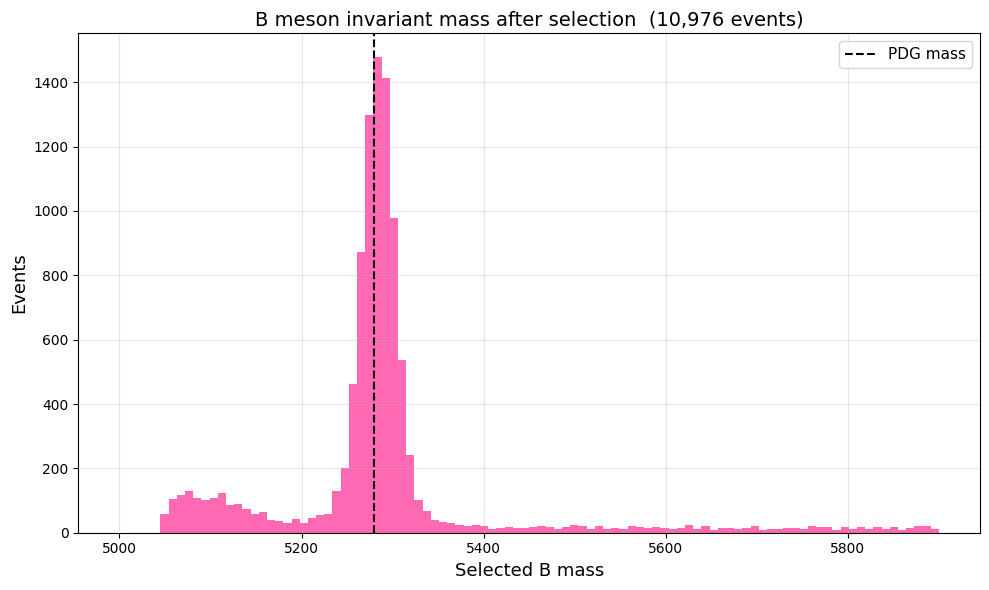

In [25]:
#Extracting the momenta again, just to rename them to make it more clear.
H1_PX = branches["H1_PX"]; H1_PY = branches["H1_PY"]; H1_PZ = branches["H1_PZ"]
H2_PX = branches["H2_PX"]; H2_PY = branches["H2_PY"]; H2_PZ = branches["H2_PZ"]
H3_PX = branches["H3_PX"]; H3_PY = branches["H3_PY"]; H3_PZ = branches["H3_PZ"]

#Finding the B mass for 1, 2 and 3 PRE-CUT (needed for the historgram plot)
m_K = 494  # MeV/c²

#Same equations as used before
def reconstruct_B_mass(PX1, PY1, PZ1, PX2, PY2, PZ2, PX3, PY3, PZ3, m):
    E1 = np.sqrt(PX1**2 + PY1**2 + PZ1**2 + m**2)
    E2 = np.sqrt(PX2**2 + PY2**2 + PZ2**2 + m**2)
    E3 = np.sqrt(PX3**2 + PY3**2 + PZ3**2 + m**2)
    E_B  = E1 + E2 + E3
    PX_B = PX1 + PX2 + PX3
    PY_B = PY1 + PY2 + PY3
    PZ_B = PZ1 + PZ2 + PZ3
    M_sq = E_B**2 - (PX_B**2 + PY_B**2 + PZ_B**2)
    return np.sqrt(np.maximum(M_sq, 0))

#The total number of entries before the cuts is found using this function:
M_B_all = reconstruct_B_mass(H1_PX, H1_PY, H1_PZ, H2_PX, H2_PY, H2_PZ, H3_PX, H3_PY, H3_PZ, m_K)

#According to the list provided above, the following selection is made
#Probability of K needs to be higher than Pi and H1_isMuon has to be zero
#The value of Vertex chi is taken from values if row 45 in previous exercise
#Setting the ProbK > 0.5 removes low probability entries and keeps the entries with higher probability of being K
selection = ((H1_ProbK > 0.5) & (H2_ProbK > 0.5) & (H3_ProbK > 0.5) & (H1_ProbK > H1_ProbPi) & (H2_ProbK > H2_ProbPi) & (H3_ProbK > H3_ProbPi) & (H1_isMuon == 0) & (H2_isMuon == 0) & (H3_isMuon == 0) & (B_VertexChi2 < 6))


#Applying the selection to find the number of entries and the fraction of the total
n_before = len(M_B_all)
n_after  = np.sum(selection)

print(f"Events before selection : {n_before:>10,}")
print(f"Events after  selection : {n_after:>10,}")
print()


#Applying the selection to the M_B_all array to obtain the array of total post cut
M_B_cut = M_B_all[selection]

#Now plotting the pre and post mass on the same histogram
#Applying these mass ranges and bins to both pre and post mass
mass_range = (5000, 5900)
bins = 100

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(M_B_all, bins=bins, range=mass_range, color="deepskyblue", alpha=0.45, density=True, label=f"Pre-cuts  ({n_before:,} events)")
ax.hist(M_B_cut, bins=bins, range=mass_range, color="hotpink", alpha=0.65, density=True, label=f"Post-cuts ({n_after:,} events)")

#Adding the pdg mass to make the peak more clear
ax.axvline(5279.34, color="black", linestyle="--", linewidth=1.5, label="PDG mass")

ax.set_xlabel("Reconstructed B mass  [MeV/c²]", fontsize=13)
ax.set_ylabel("Entries", fontsize=13)
ax.set_title("Invariant mass: pre- and post-selection", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


#Plotting post selection
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(M_B_cut, bins=bins, range=mass_range, color="hotpink")

ax.axvline(5279.34, color="black", linestyle="--", linewidth=1.5, label="PDG mass")

ax.set_xlabel("Selected B mass", fontsize=13)
ax.set_ylabel("Events", fontsize=13)
ax.set_title(f"B meson invariant mass after selection  ({n_after:,} events)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



# **Answers to theory:**
#How much of your data did you throw away? Was this a good idea? :(
  We threw away a whole lot of entries, but this is good as it will delete most of the noise. The statistical power will decrease as the sample decreases, but with the cuts it will create a peak around the pdg mass and increase the SNR.

#What do you notice about your histogram now?
Compared to the first plot, the peak correlates well with the pdg mass, which is expected. In the first historgram, the mass did not fall within the peak, but after removing most of the noise, it does. This is good. It is also more of a gaussian fit than before, which correlates to small errors due to equipment or outliers in the noise.

**Next Exercise**

#How do we count the number of events?

We now have a histogram of events that we have reconstructed as a B meson. But some of these events are caused by a co-incidence of events which would still occur if there were no B mesons actually produced. We call this the background. Background and signal are indistinguishable now as the detector cannot tell the difference and our cuts were unable to remove the events for physics reasons. We can do some statistical analysis, if we know the approximate shapes of our signal and our background. Just like a least-squares fitting we can run a fit routine to minimise the error between the fitted curve and our data. As an example, if we know our data has an exponential background and a gaussian signal:

![Gaussian+Exp Background](https://twiki.cern.ch/twiki/pub/RooStats/RooStatsTutorialsJune2013/GausExpModelFit.png)

Here the red line represents our signal, the blue dotted line is our background and the solid blue line is our combined curve. The graph also shows the number of signal events and the number of background events. The signal now is a tiny fraction of the total data shown in the plot.

In order to do this, we need to build a fit model, around which the software can try to fit our data.

We use RooFit for this, which includes:
* Gaussian
* Exponential
* Chebychev
* Crystal Ball
* Breit-Wigner

As well as several other choices.

Typically exponential and Chebychev functions are used for background and Gaussian, Crystal Ball and Breit-Wigner are used for signal. We can also combine them (e.g. 1 crystal ball, 1 gaussian, 1 exponential) in various ways.

In [26]:
# Probably handy to use a package like lmfit to help us with the models we might want to use, then use scipy to fit

!pip install lmfit

# check out its documentation for what shapes it can handle for you! https://pypi.org/project/lmfit/

# it can do the whole fitting story and output results too :)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00


In [27]:
#use my example of creating a PDF (far far) above to do a fit to your data. Start with one component, think about making a number 2 component plot - so we have a part for the background and a part for the signal.

# if your cut is very strict above, you may actually get better results by being less strict, give yourself more data and more events to run through the fitting procedure.

Fit results:
  Signal fraction   : 0.67 ± 0.01
  Mean (μ)          : 5284.75 ± 0.22 MeV/c²
  Width (σ)         : 17.62 ± 0.23 MeV/c²
 Signal events      : 7,304
  Background events : 3,672


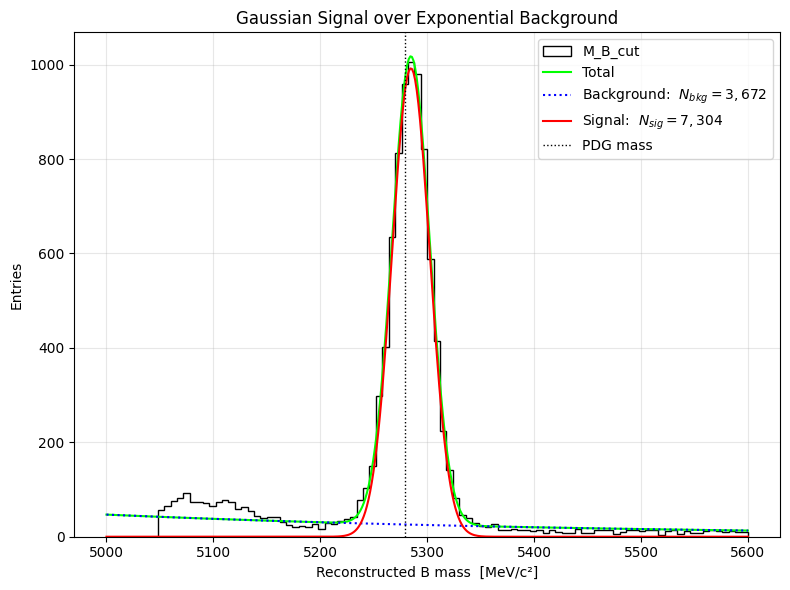

In [28]:
#Additional package needed for fitting
from scipy.optimize import curve_fit

#Setting the needed parameters for the histogram
n_bins = 100
x_min, x_max = 5000, 5600
n_entries = len(M_B_cut) #Number of entries after selection, as in previous exercise
bin_width = (x_max - x_min) / n_bins #Same settings as example

#Creating the plot
fig, ax = plt.subplots(figsize=(8, 6))

#Same as example, constructing the entries after selection to see the fit and to find the optimal bin width
counts, bin_edges, _ = ax.hist(M_B_cut, bins=n_bins, range=(x_min, x_max), histtype="step", color="black", label="M_B_cut")

#The centers of each bin, from: https://stackoverflow.com/questions/72688853/get-center-of-bins-histograms-python
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

#Fitting the signal and the background as shown in the example plot. Using gaussian for the signal and exponential for background, as indicated
#First we evaluate the Gaussian and exponential probability density function
def gaussian_pdf(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

#Exponential PDF on given range
#Lam (background decay) is found to be zero, so not needed but added for completion
def exponential_pdf(x, lam, x0=5000):
    return lam * np.exp(-lam * (x - x0))

#Then for the combined curve to describe the data as combination of gaussian and exponential
#f_sig is the signal fraction that describes the percentage of gaussian and then 1-f_sig describes the exponential
def total_model(x, f_sig, mu, sigma, lam):
    return (f_sig * gaussian_pdf(x, mu, sigma) + (1 - f_sig) * exponential_pdf(x, lam))


#Scale PDF to histogram counts, same as the example. The total model is a probability and the histogram are counts of events, so we rescale it to fit
#The rescale is: counts = PD (total_model) × total events (n_entries) × bin width
def fit_counts(x, f_sig, mu, sigma, lam):
    return total_model(x, f_sig, mu, sigma, lam) * n_entries * bin_width

#Starting point needed for curve_fit
#If the starting is None, then it will be 1 for all parameters, which would not be a good estimation for this case. From: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
#We guess: 0.3 is signal fraction (low as shown in example above), 5279.34 is pdg mass, 19 for detector resolution, 0.02 for decay constant. These numbers can be anywhere in between the bounds
p0 = [0.3, 5279.34, 19, 0.02]
bounds = ([0, 5200, 5, 1e-5], [1, 5380, 60, 0.05])

#To find the statistical significance of the fit we find the uncertainties and standard deviations
#The curve_fit returns popt (best fit parameters) and pcov (uncertainty of popt parameters). From: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
popt, pcov = curve_fit(fit_counts, bin_centres, counts, p0=p0, bounds=bounds, maxfev=10000)

#From that same source the standard deviation for the parameters is obtained using the following equation:
perr = np.sqrt(np.diag(pcov))

#This is tupple unpacking to assign names to the array of popt and perr (its easier): https://www.w3schools.com/python/python_tuples_unpack.asp
f_sig, mu, sigma, lam = popt
f_sig_err, mu_err, sigma_err, lam_err = perr

#Now to find the number of signal events and background events as the example does too
n_signal = f_sig * n_entries #Fraction of signal multiplied by total number of entries
n_bkg    = (1 - f_sig) * n_entries #1 minus fraction of signal multiplied by total number of entries


#Now to visualize, we print the results with decimal numbers
print("Fit results:")
print(f"  Signal fraction   : {f_sig:.2f} ± {f_sig_err:.2f}")
print(f"  Mean (μ)          : {mu:.2f} ± {mu_err:.2f} MeV/c²")
print(f"  Width (σ)         : {sigma:.2f} ± {sigma_err:.2f} MeV/c²")
print(f" Signal events      : {n_signal:,.0f}")
print(f"  Background events : {n_bkg:,.0f}")

#Now to create the curves that need to be plotted

#Create x values for drawing the fitted function
x = np.linspace(x_min, x_max, 400)

#We need three curves: signal, background and total
y_total  = fit_counts(x, f_sig, mu, sigma, lam) #Fit_counts needs 5 entries, this is the same as done above

#Apply the same scaling as done before
y_signal = f_sig       * gaussian_pdf(x, mu, sigma)    * n_entries * bin_width
y_bkg    = (1 - f_sig) * exponential_pdf(x, lam)       * n_entries * bin_width

#Plotting the y-curves against x
ax.plot(x, y_total, color="lime", label= "Total")

ax.plot(x, y_bkg, color="blue", linestyle="dotted", label=f"Background:  $N_{{bkg}}={n_bkg:,.0f}$")

ax.plot(x, y_signal, color="red", label=f"Signal:  $N_{{sig}}={n_signal:,.0f}$")

#Plotting the pdg mass to see where the peak is expected
ax.axvline(5279.34, color="black", linestyle=":", linewidth=1, label="PDG mass")



ax.set_title("Gaussian Signal over Exponential Background")
ax.set_xlabel("Reconstructed B mass  [MeV/c²]")
ax.set_ylabel("Entries")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Using this structure, you can in theory build whatever models you like!

Some recommendations (but not necessary to do all):-



*   Gauss+Exponential (as above)
*   Crystal Ball + Exponential
*   Gauss+Crystal Ball+Exponential (now you need to weigh the two signal peaks and then the total signal against total background)
*   Gauss+Chebychev
*   Two Crystal Balls + Exponential

So how good was the fit, and how many events do you have?

You can use the signal shape, the bin widths and the quad from scipy.integrate function to "count" how many events lie under your signal peak,  not including the background events - this is what we actually want.

It will also return to you an error - check in the scipy documentation about what that actually means....

In [29]:
#find the area under your curve(s)! maybe make a pretty little table...

In [30]:
#Import the quad package to use the integration function: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html
from scipy.integrate import quad

#Define the scaled signal function to integrate (same scaling as previous exercise)
def signal_counts(x):
    return f_sig * gaussian_pdf(x, mu, sigma) * n_entries * bin_width

#Integrate the signal over the full range
n_sig_integral, integration_error = quad(signal_counts, x_min, x_max)
#According to scipy, the error the function returns explains how well the function computed the integral (the absolute integration error). We want it to be as small as possible for a gaussian fit


#Pretty table of results
#The <# are the spacing between the columns
print("=" * 52) #Number of equal signs
print(f"{'Parameter':<30} {'Value':>10} {'Error':>10}")
print("=" * 52)
print(f"{'Total entries':<30} {n_entries:>10,.0f}")
print(f"{'Signal events':<30} {n_signal:>10,.0f} {f_sig_err * n_entries:>10,.0f}")
print(f"{'Background events':<30} {n_bkg:>10,.0f}")
print("-" * 52)
print(f"{'Signal (from integral)':<30} {n_sig_integral:>10,.1f} {integration_error:>10.2e}")
print("=" * 52)

print("The small integration error indicates that the fit is good.")

Parameter                           Value      Error
Total entries                      10,976
Signal events                       7,304         86
Background events                   3,672
----------------------------------------------------
Signal (from integral)           43,823.4   1.54e-06
The small integration error indicates that the fit is good.


#Counting

So we have now loaded our data; we have reconstructed information about the mother B meson and we have cut away any data which looks like it might not be what we are looking for. We have then plotted histograms of the mass of the B meson and used this to fit a model, a function to describe the events there. We now have to identify which of our events belong to the B<sup>+</sup> and how many of them belong to B<sup>-</sup>.

To do this, should split out data into two groups (and throw away data which doesn't comply with either decay)

We will be looking for the events which are


B<sup>+</sup>->K<sup>+</sup> + K<sup>+</sup>  + K<sup>-</sup>

or

B<sup>-</sup>->K<sup>-</sup> + K<sup>-</sup>  + K<sup>+</sup>

We can look for the number of positive and negative charges in H1, H2 and H3 (using the variable ```H1_Charge``` etc.). If we have 0 or 3 positive charges, we should throw the event away and if we have 1 it should be assigned be a B<sup>-</sup>, with 2 it should be a B<sup>+</sup>

Once we have defined if it's a B<sup>+</sup> or a B <sup>-</sup>, we should go ahead and ensure the pre-selection is applied and then plot our B mass, and fit the model to find the yield.

We can then calculate the assymetry from this equation:

$A=\frac{(N^{B-}-N^{B+})}{(N^{B-}+N^{B+})}$

Where N<sup>B+/- </sup> is the number of events found from the fitted yield of the signal from each data set.

The uncertainty on this result is given by:

$\sigma_A=\sqrt\frac{1-A^2}{N^{B-}+N^{B+}}$

Calculate these two values for your data and print them below:

B⁺ candidates (after selection): 5,749
B⁻ candidates (after selection): 5,227


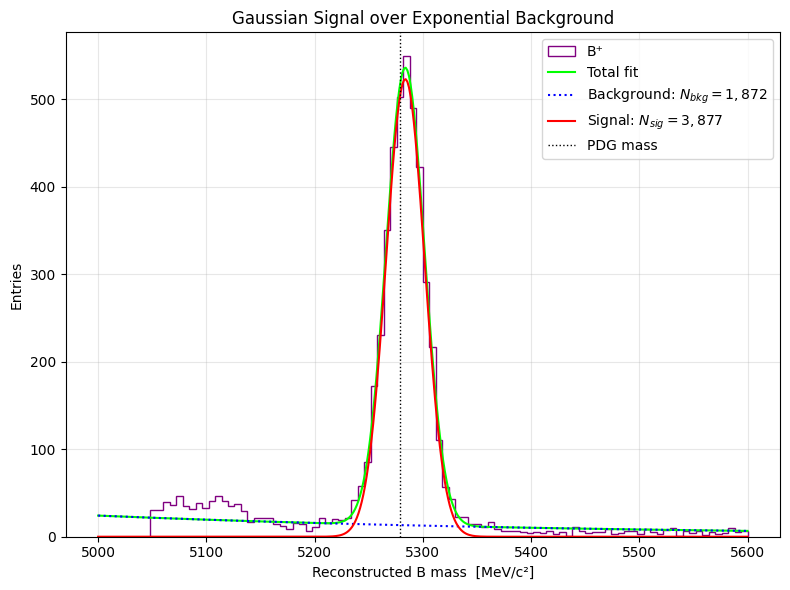

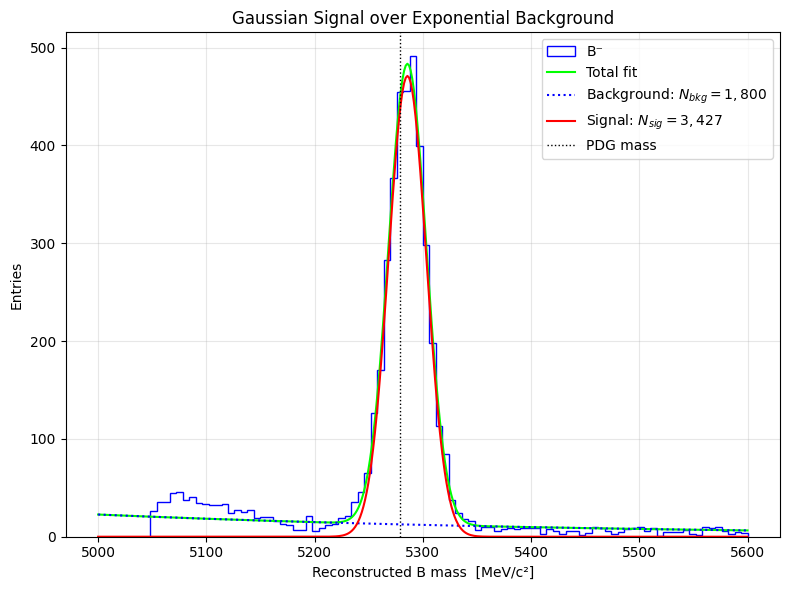


Parameter                                     Value
N(B⁺) from fit                             23,260.4
N(B⁻) from fit                             20,561.2
Asymmetry  A                                -0.0616
Uncertainty σ_A                              0.0048


In [31]:
#The first steps are the same as the ones we did before, but we need to rename them so the values do not get mixed up and we end up with the same plots
#Extract the charges from the files, but converting arrays so .astype works in next step
H1_Charge = np.asarray(branches["H1_Charge"])
H2_Charge = np.asarray(branches["H2_Charge"])
H3_Charge = np.asarray(branches["H3_Charge"])

#Counting the number of positive charges of the daughters for each event, where postive is +1 and negative is -2 (shown in row 45 above)
n_positive = (H1_Charge > 0).astype(int) + (H2_Charge > 0).astype(int) + (H3_Charge > 0).astype(int)

#Defining when an event is B+ or B- and then also using the selection from above to remove particles that are not B mesons
selection_Bplus  = (n_positive == 2) & selection
selection_Bminus = (n_positive == 1) & selection

#This function gives the B+ and B- mass values
M_B_plus  = M_B_all[selection_Bplus]
M_B_minus = M_B_all[selection_Bminus]

#Len function gives the total number of B+ and B- particles that passed the charge selection and the selection of it being background
print(f"B⁺ candidates (after selection): {len(M_B_plus):,}")
print(f"B⁻ candidates (after selection): {len(M_B_minus):,}")

#Fitting the model to find the yield, same as before
def fit_sample(M_B_sample, label, color_hist="black"):
    n_bins   = 100
    x_min, x_max = 5000, 5600
    n_entries    = len(M_B_sample)
    bin_width       = (x_max - x_min) / n_bins

    fig, ax = plt.subplots(figsize=(8, 6))
    counts, bin_edges, _ = ax.hist(M_B_sample, bins=n_bins, range=(x_min, x_max), histtype="step", color=color_hist, label=label)

#Use the same definitions as before, just naming slightly different to not mix them
    def total_modelB(x, f_sig, mu, sigma, lam):
        return (f_sig * gaussian_pdf(x, mu, sigma) + (1 - f_sig) * exponential_pdf(x, lam))

    def fit_countsB(x, f_sig, mu, sigma, lam):
        return total_modelB(x, f_sig, mu, sigma, lam) * n_entries * bin_width


    p0     = [0.3, 5279.34, 19, 0.02]
    bounds = ([0, 5200, 5, 1e-5], [1, 5380, 60, 0.05])

    popt, pcov = curve_fit(fit_countsB, bin_centres, counts, p0=p0, bounds=bounds, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))

    f_sig_fit, mu_fit, sigma_fit, lam_fit = popt
    f_sig_err_fit = perr[0]

    n_signal_fit = f_sig_fit * n_entries
    n_bkg_fit    = (1 - f_sig_fit) * n_entries


#Define the scaled signal function to integrate
    def signal_countsB(x):
        return f_sig_fit * gaussian_pdf(x, mu_fit, sigma_fit) * n_entries * bin_width

#Using the quad function to integrate the area over the full range
    n_sig_integral, integration_error = quad(signal_countsB, x_min, x_max)

    #Plotting the curves
    x_plot   = np.linspace(x_min, x_max, 400)
    y_total  = fit_countsB(x_plot, *popt)
    y_signal = f_sig_fit       * gaussian_pdf(x_plot, mu_fit, sigma_fit) * n_entries * bin_width
    y_bkg    = (1 - f_sig_fit) * exponential_pdf(x_plot, lam_fit)       * n_entries * bin_width

    ax.plot(x_plot, y_total,  color="lime",  label="Total fit")
    ax.plot(x_plot, y_bkg,    color="blue",  linestyle="dotted", label=f"Background: $N_{{bkg}}={n_bkg_fit:,.0f}$")
    ax.plot(x_plot, y_signal, color="red", label=f"Signal: $N_{{sig}}={n_signal_fit:,.0f}$")
    ax.axvline(5279.34, color="black", linestyle=":", linewidth=1, label="PDG mass")

    ax.set_title(f"Gaussian Signal over Exponential Background")
    ax.set_xlabel("Reconstructed B mass  [MeV/c²]")
    ax.set_ylabel("Entries")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return n_sig_integral   #Ending the function

#Fitting the number of B+ and B- to gaussian and exponential and returns the actual number of B+ and B- entries.
N_Bplus  = fit_sample(M_B_plus,  label="B⁺", color_hist="purple")
N_Bminus = fit_sample(M_B_minus, label="B⁻", color_hist="blue")

#Calculating the asymmetry with the given functions
A       = (N_Bminus - N_Bplus) / (N_Bminus + N_Bplus)
sigma_A = np.sqrt((1 - A**2) / (N_Bminus + N_Bplus))

#Showing the results in a table as before
print("\n" + "=" * 52)
print(f"{'Parameter':<30} {'Value':>20}")
print("=" * 52)
print(f"{'N(B⁺) from fit':<30} {N_Bplus:>20,.1f}")
print(f"{'N(B⁻) from fit':<30} {N_Bminus:>20,.1f}")
print(f"{'Asymmetry  A':<30} {A:>20.4f}")
print(f"{'Uncertainty σ_A':<30} {sigma_A:>20.4f}")
print("=" * 52)

#Congratulations!

You just made your first LHCb physics analysis. Does this seem like a reasonable result? Did we explain why we have an excess of mass in the Universe?

**The results should show that there is an asymmetry between the matter and antimatter B mesons. If there is no asymmetry, then matter and antimatter exist in the same amount, which is not the case. There should be more matter (or antimatter) than antimatter (or matter). The uncertainy that is obtained is very small, so maybe something went wrong in the calculations, as I expected a larger asymmetry.**

## **Bonus content only below here:**

To make a further anaysis, we can look into the intermediate processes.

We have so far considered only that the B meson ultimately decays into three kaons. It may be that on the way, the B meson first decays into a Kaon and another particle, and then from that particle to two Kaons.

We would expect this to be one of three possible modes (for B<sup>+</sup>):

$R^{++} \rightarrow K_1^+ +K_2^+$

(we don't expect this to happen because of the like charges in the Kaons)

$R^0 \rightarrow K_1^+ +K_3^-$

$R^0 \rightarrow K_2^+ +K_3^-$

(Expect symmetric arrangements for B<sup>-</sup>)

To analyse the intermediate states we can measure the invarient masses of the intermediate states and then plot them on what is called a Dalitz plot (this is a 2D plot with two different two body decays (from the three body decay) on each axis)

![Dalitz Plot](https://slideplayer.com/slide/15960097/88/images/15/Dalitz+plot%3A+%CE%9B+c+%2B+%E2%86%92%F0%9D%91%9D+%F0%9D%90%BE+%E2%88%92+%F0%9D%9C%8B+%2B.jpg)


In [32]:
#Define a function to find the invarient mass of two given Kaons

In [33]:
#Then, ensuring you're still taking the data after the selection, make a Dalitz plot. This is a 2-D scatter plot (use e.g. TH2F to make the plot where we used TH1F before)
#Choose an appropriate binning in your scatter

We can further improve our plot, since two sets of particles on each axis are exactly the same (one positive Kaon, one negative Kaon). So we can plot the maximum of the two values on one axis and the minimum on the other. We can use a quick numpy check and then plot those values.

In [34]:
#Make the revised Dalitz plot here for B+ mesons

In [35]:
#Make the revised Dalitz plot here for B- mesons

In [36]:
#Where we have a higher density of points (or a bigger value in the bin) this is indication of an intermediate resonance
#Check out the possible resonances you have found in the PDG (http://pdg.lbl.gov/2020/tables/contents_tables.html)